In [22]:
import torch
import os
import argparse
import copy

models_dir = "trained_models"

model_metadata = {}

for root, _, files in os.walk(models_dir):  
    for filename in files:
        if filename.endswith('.pth'):
            checkpoint_path = os.path.join(root, filename)
            
            torch.serialization.add_safe_globals([argparse.Namespace])
            checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
            
            model_metadata[str(filename)] = {
                k: copy.deepcopy(v) 
                for k, v in checkpoint.items() 
                if k != "model"
            }

In [25]:
from pprint import pprint

models = model_metadata.keys()

print("Models: ", models)
print("Sample Model Dict: ")
pprint(model_metadata[list(models)[0]])

Models:  dict_keys(['radimagenet18_vqa_baseline.pth', 'radimagenet50_vqa_baseline1.pth'])
Sample Model Dict: 
{'epoch': 10,
 'loss_history': [2.678392713334825,
                  1.104000955687629,
                  0.7490984157721201,
                  0.5914737441804674,
                  0.482448770403862,
                  0.41272164358033075,
                  0.36231510592831506,
                  0.34388565997282666,
                  0.306790319747395,
                  0.2925025653839111],
 'model_name': 'radimagenet18_vqa_baseline',
 'train_f1_history': [0.2770252330713803,
                      0.5604931465709381,
                      0.6448498254385965,
                      0.7051549531798121,
                      0.7538994752931,
                      0.776823629598972,
                      0.7941042204264254,
                      0.7962912506419192,
                      0.8113022479043743,
                      0.8255980493334983],
 'val_f1_history': [0.390901739609

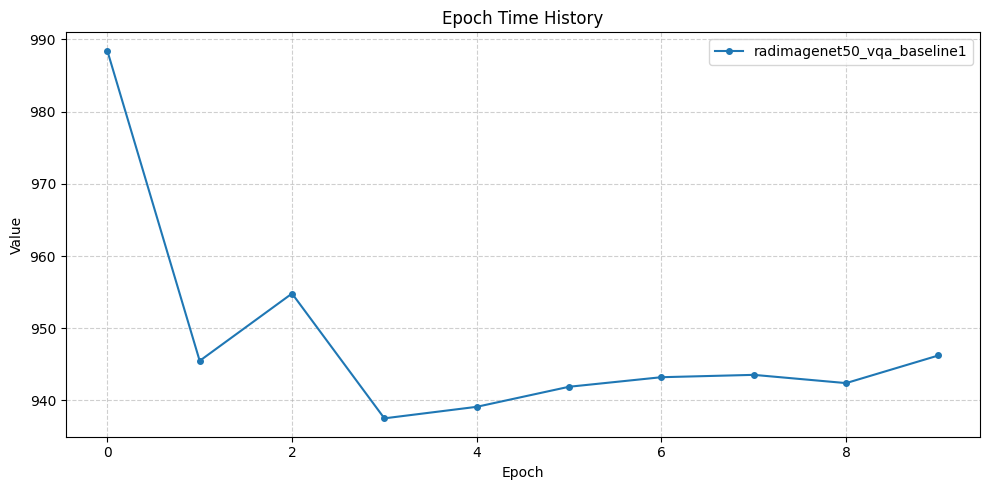

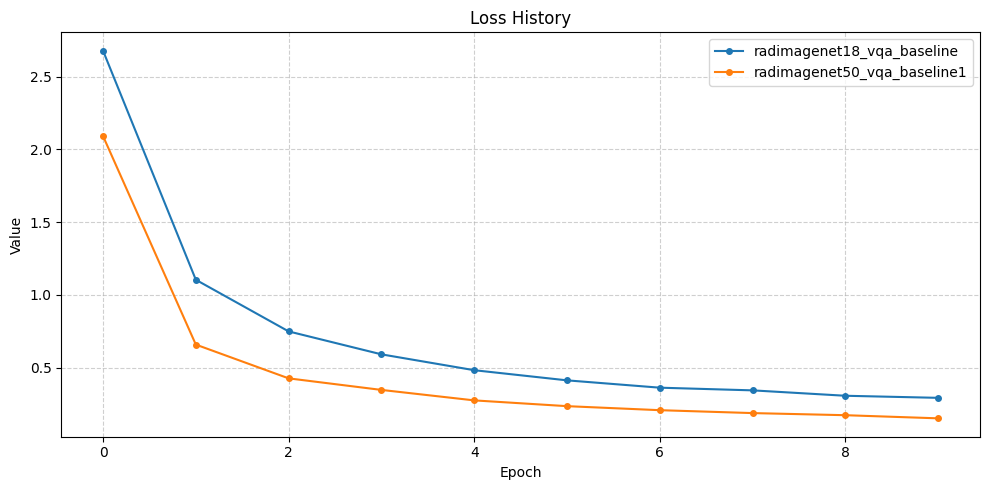

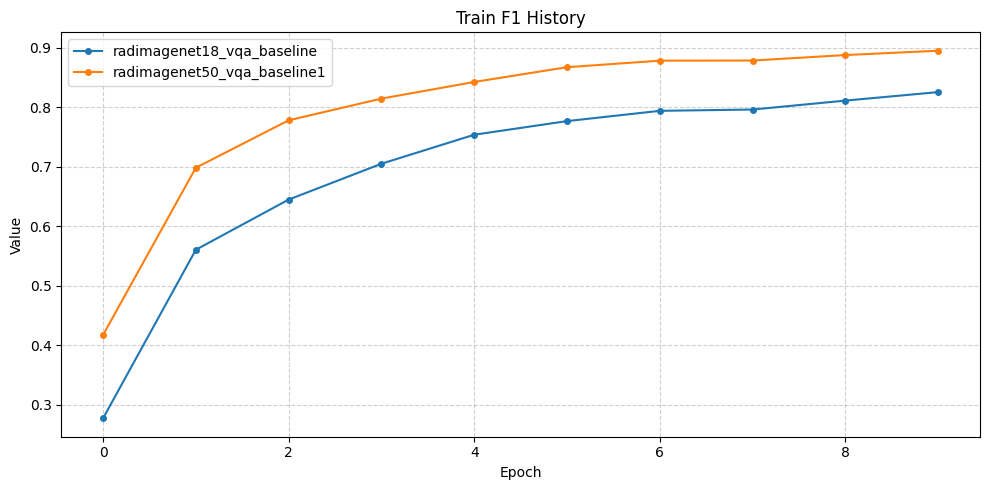

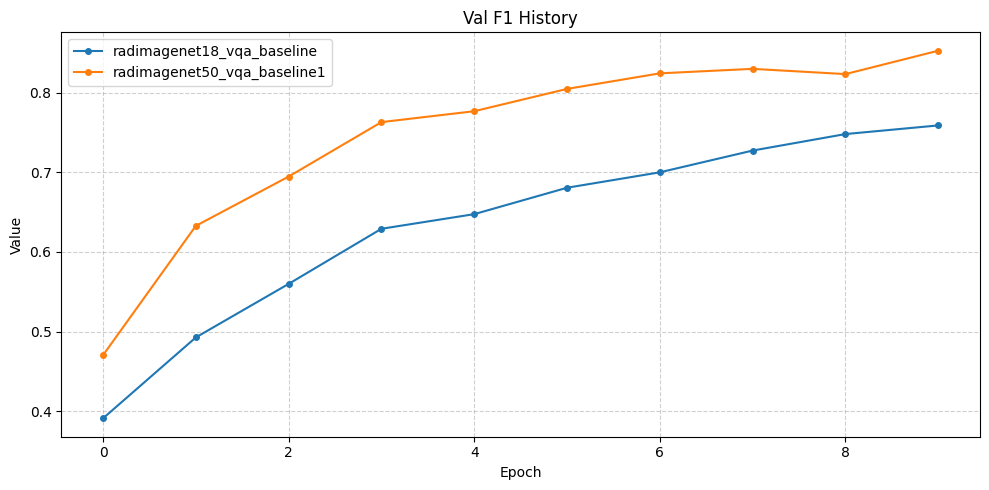

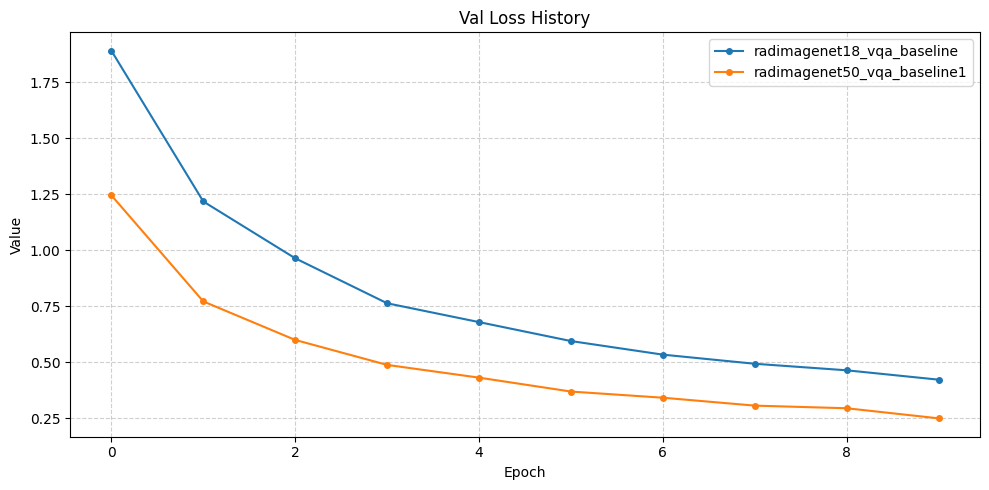

In [26]:
import matplotlib.pyplot as plt

metrics = {key for model in model_metadata.values() for key in model if 'history' in key}

for metric in sorted(metrics):
    plt.figure(figsize=(10, 5))
    
    for model_filename, data in model_metadata.items():
        if metric in data:
            label = data.get('model_name', model_filename)
            plt.plot(data[metric], label=label, marker='o', markersize=4)
    
    plt.title(f"{metric.replace('_', ' ').title()}")
    plt.xlabel("Epoch")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()